In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rc
import xarray as xr
import pyart
from netCDF4 import Dataset
from functions import *
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from metpy.plots import USCOUNTIES
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

# plotting set up
plt.rcParams['axes.labelweight'] = 'normal'
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'
rc('font', family='sans-serif')
rc('font', weight='normal', size=15)
rc('figure', facecolor='white')


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [2]:
def snr_cmap():
    cdict11= {'red':  ((  0.0, 150/255, 150/255),
                    ( 2/19, 207/255, 207/255),
                    ( 6/19,  67/255,  67/255),
                    ( 7/19, 111/255, 111/255),
                    ( 8/19,  53/255,  17/255),
                    (11/19,   9/255,   9/255),
                    (12/19,     1.0,     1.0),
                    (14/19,     1.0,     1.0),
                    (16/19, 113/255,     1.0),
                    (17/19,     1.0,     1.0),
                    (18/19, 225/255, 178/255),
                    (  1.0,  99/255,  99/255)),

            'green': ((  0.0, 145/255, 145/255),
                    ( 2/19, 210/255, 210/255),
                    ( 6/19,  94/255,  94/255),
                    ( 7/19, 214/255, 214/255),
                    ( 8/19, 214/255, 214/255),
                    (11/19,  94/255,  94/255),
                    (12/19, 226/255, 226/255),
                    (14/19, 128/255,     0.0),
                    (16/19,     0.0,     1.0),
                    (17/19, 146/255, 117/255),
                    (18/19,     0.0,     0.0),
                    (  1.0,     0.0,     0.0)),

            'blue':  ((  0.0,  83/255,  83/255),
                    ( 2/19, 180/255, 180/255),
                    ( 4/19, 180/255, 180/255),
                    ( 6/19, 159/255, 159/255),
                    ( 7/19, 232/255, 232/255),
                    ( 8/19,  91/255,  24/255),
                    (12/19,     0.0,     0.0),
                    (16/19,     0.0,     1.0),
                    (17/19,     1.0,     1.0),
                    (18/19, 227/255,     1.0),
                    (  1.0, 214/255, 214/255))
            }
    cmap = colors.LinearSegmentedColormap(name='radar_NEXRAD_Zhh', segmentdata=cdict11)
    
    return cmap

In [14]:
f = Dataset(fhalo + dlid)
f.variables.keys()

dict_keys(['base_time', 'time_offset', 'range', 'azimuth', 'elevation', 'velocity', 'snum', 'hour'])

In [15]:
fhalo = "/data/arrcwx/robbyfrost/halo/20250425/"
dlid = "dltruckdlcsmDL1.b1.20250425_reproc.cdf"
# dlid = "dltruckdlcsmDL1.b1.20250425.000000.cdf"
dhea = "LIDR_TRUCK_20250425_MM.nc"
dfig = "/home/robbyfrost/Figures/halo/"

# read lidar data
f = Dataset(fhalo + dlid)
vr = f.variables['velocity'][:]
snum = f.variables['snum'][:]
az = f.variables['azimuth'][:]
el = f.variables['elevation'][:]
hour = f.variables['hour'][:]
# heading = f.variables['heading'][:]
r = f.variables['range'][:]
# snr = 10 * np.log10(f.variables['intensity'][:]-1)
time = f.variables['base_time'][0] + f.variables['time_offset'][:]
unique_snum = np.unique(snum)
f.close()

# read heading information
m = Dataset(fhalo + dhea)
m_heading = m.variables['gps_dir'][:]
c_heading = m.variables['compass_dir'][:]
mtime = m.variables['epochtime'][:]
lat = m.variables['lat'][:]
lon = m.variables['lon'][:]
m.close()

Saved to: /home/robbyfrost/Figures/halo/20250425_200722_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_200828_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_200934_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_201029_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_201704_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_201912_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_202021_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_202130_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_202236_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_204717_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_204827_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_204936_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_205045_vr_zeta.png

Saved to: /home/robbyfrost/Figures/halo/20250425_205155_vr_zeta.png

Saved to: /home/robbyfrost/Figures

ValueError: x and y arguments to pcolormesh cannot have non-finite values or be of type numpy.ma.MaskedArray with masked values

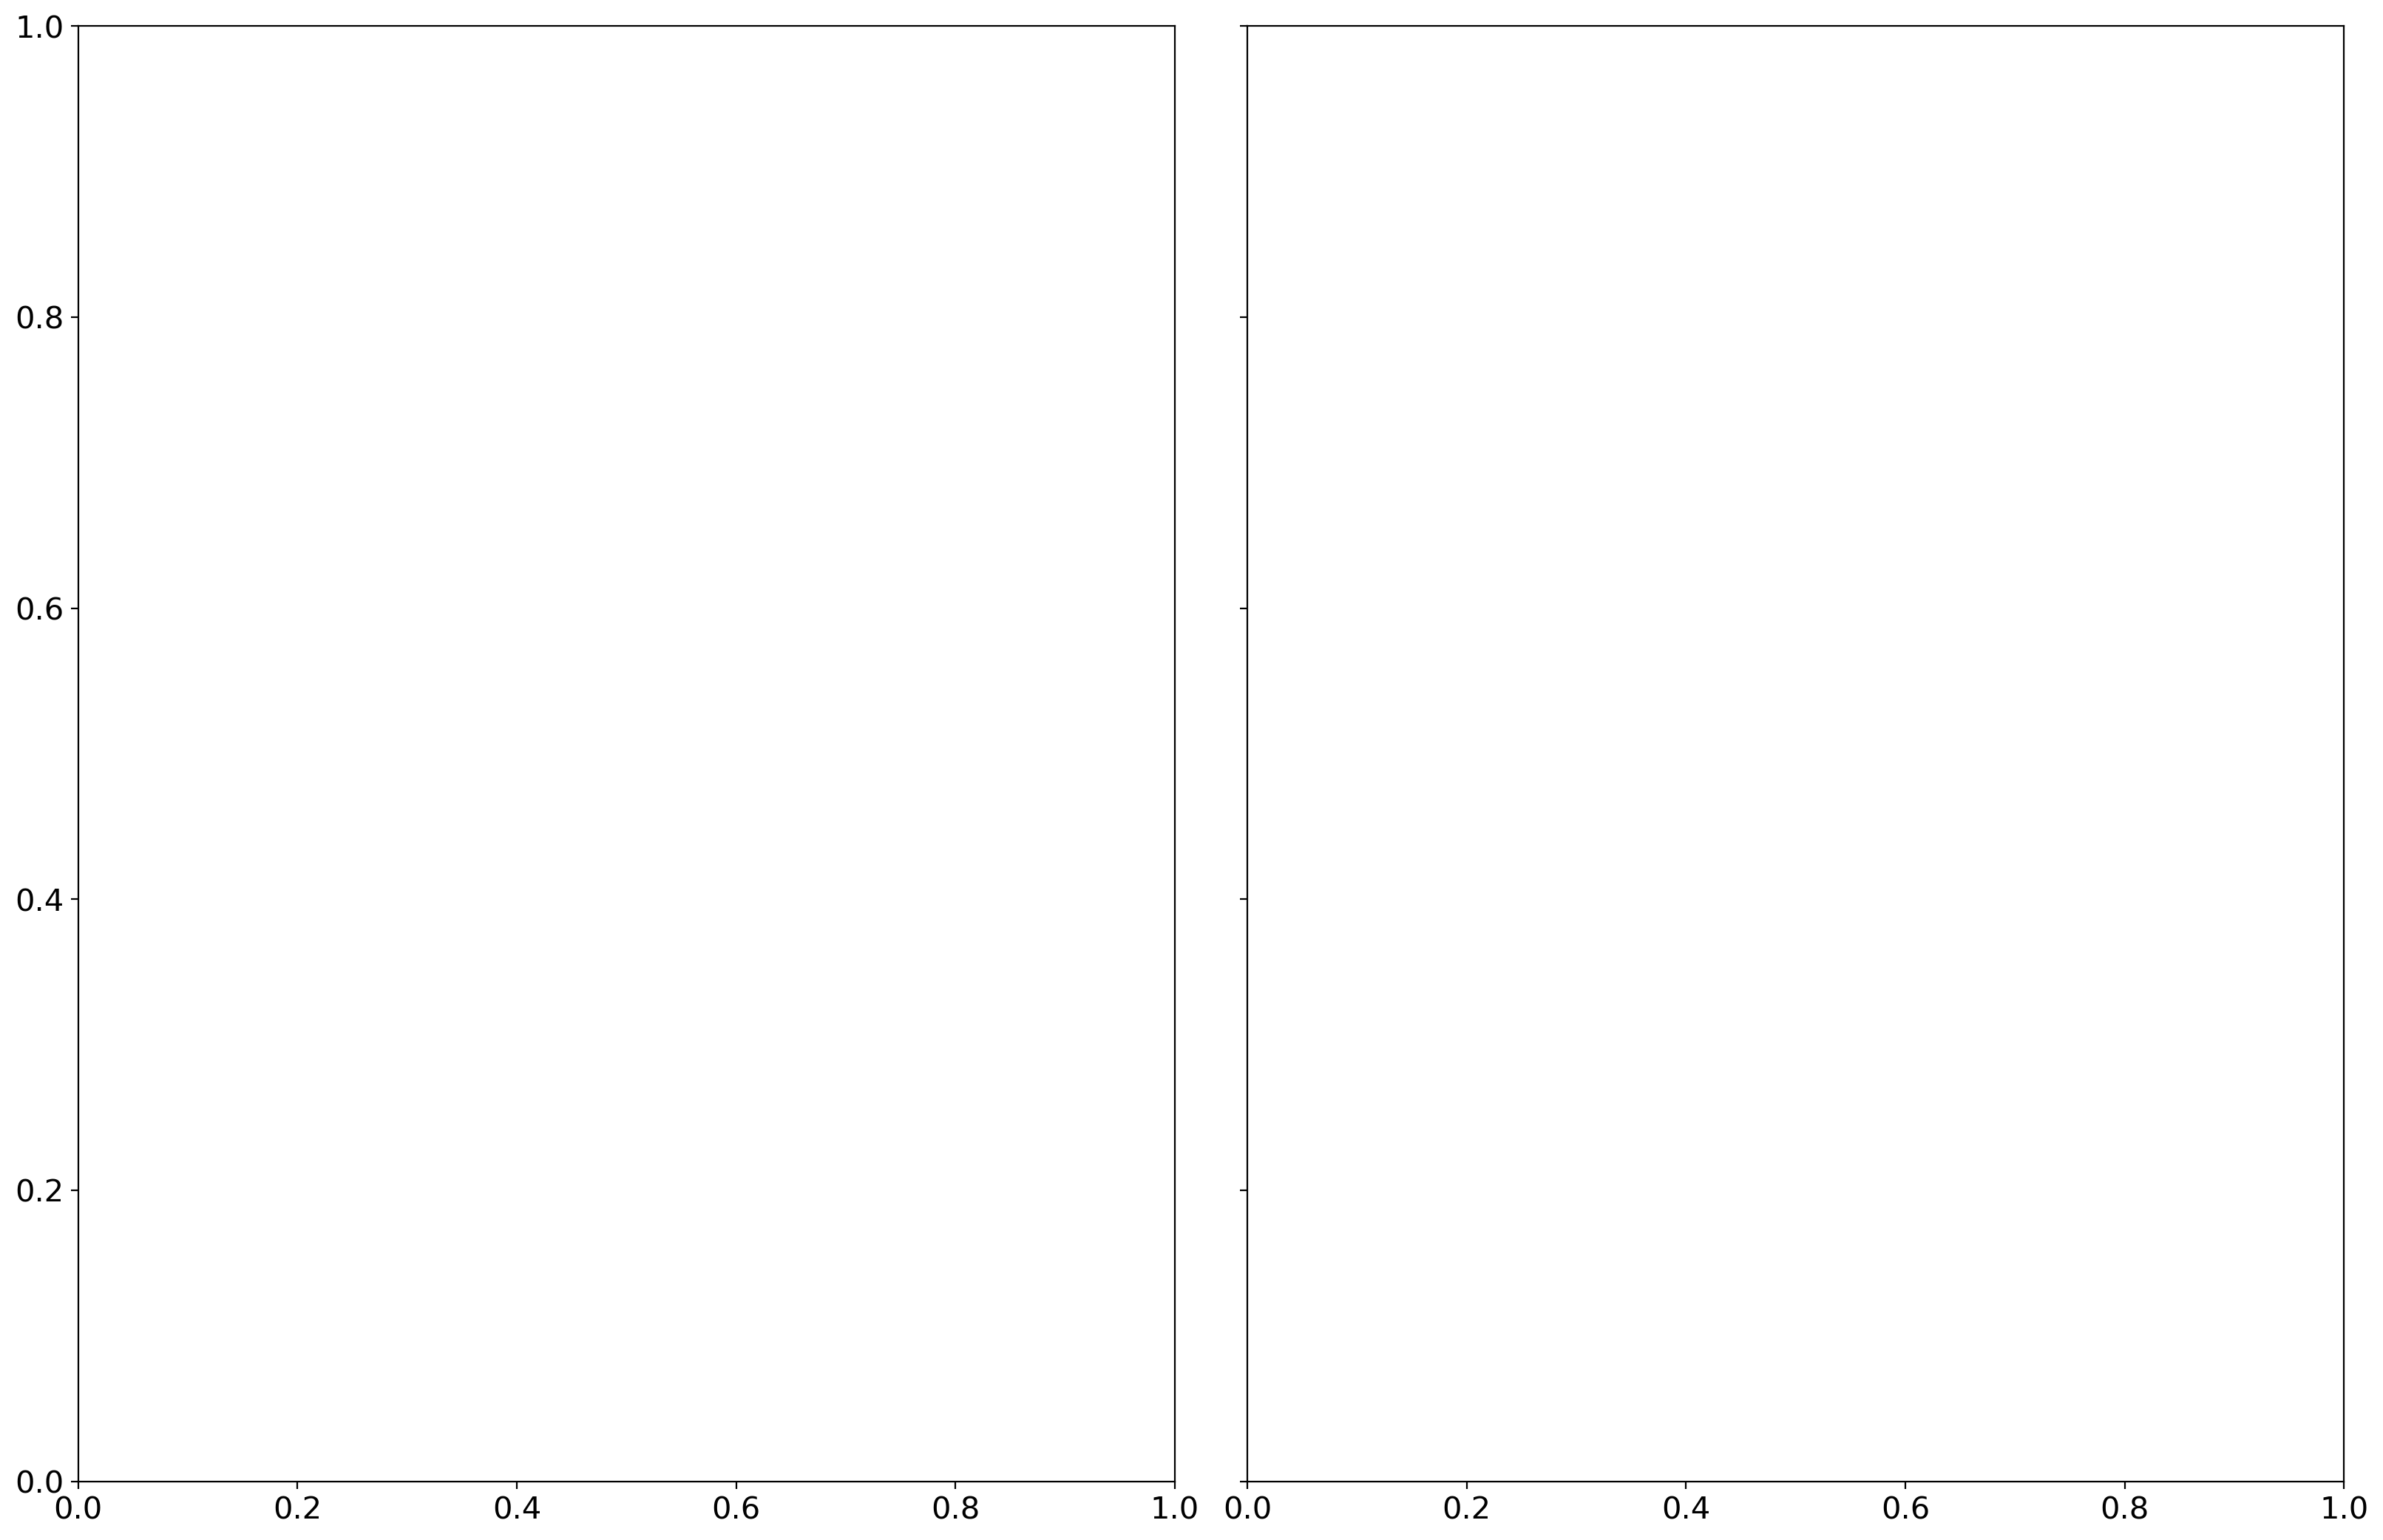

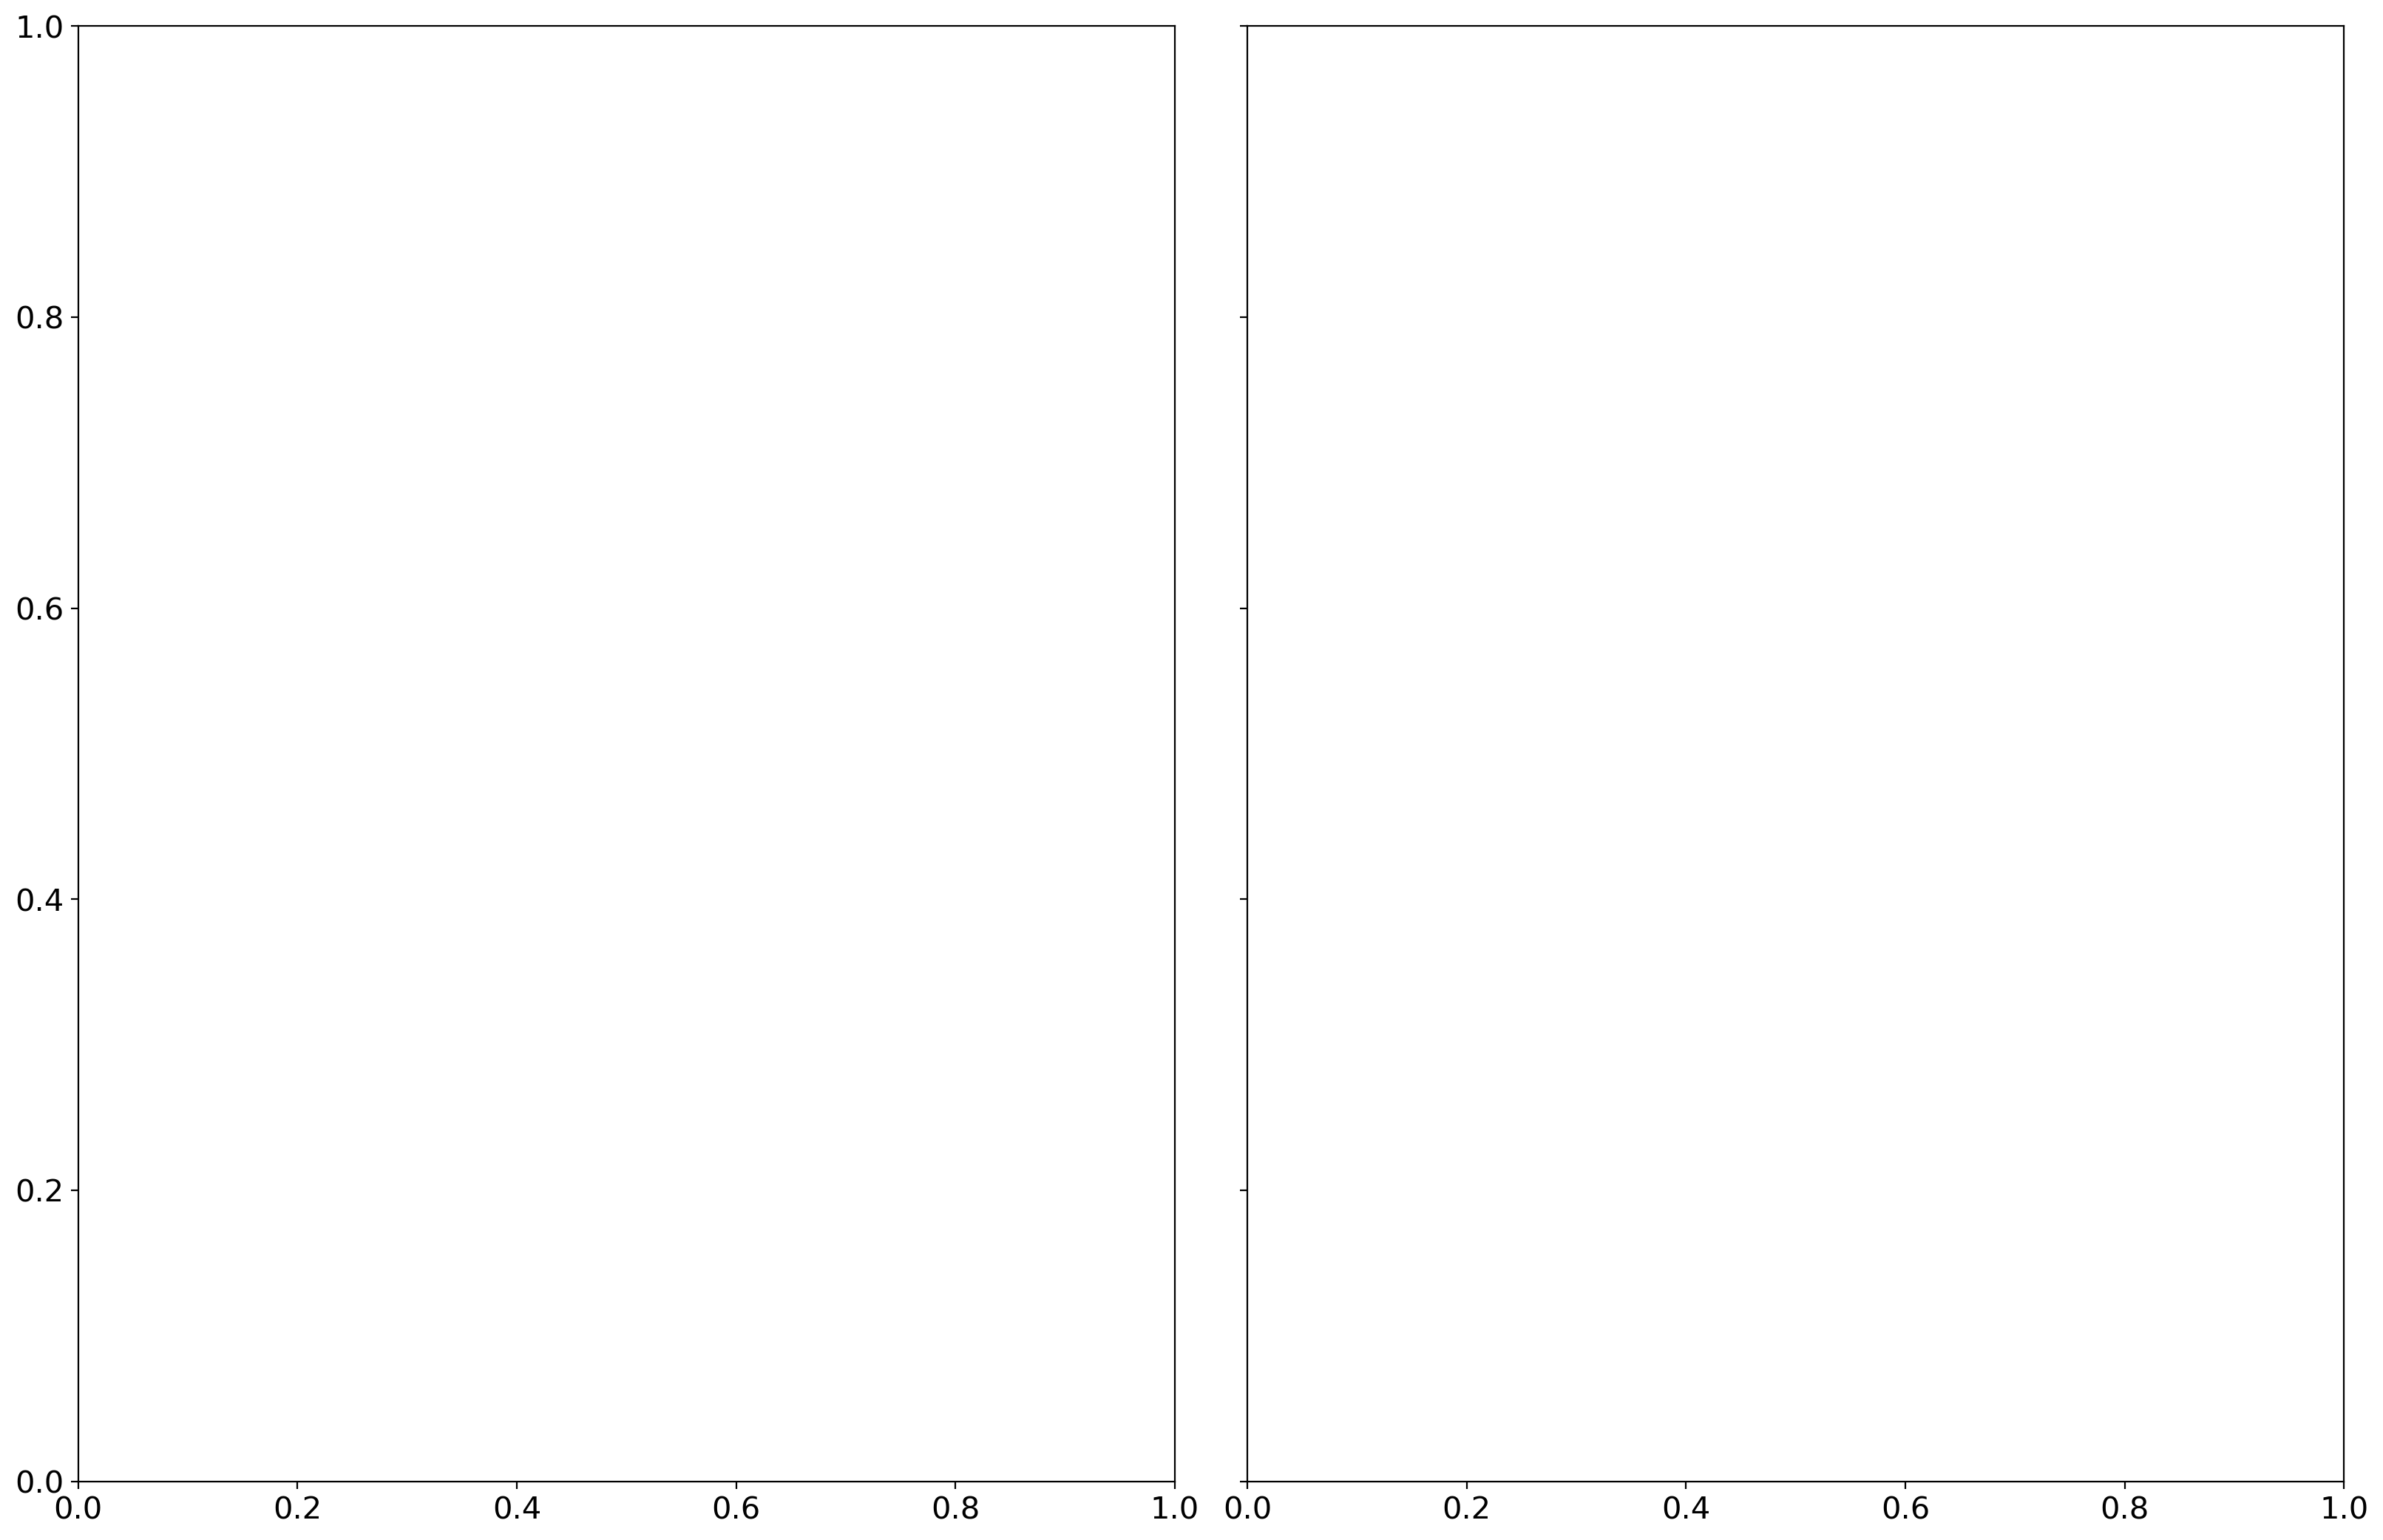

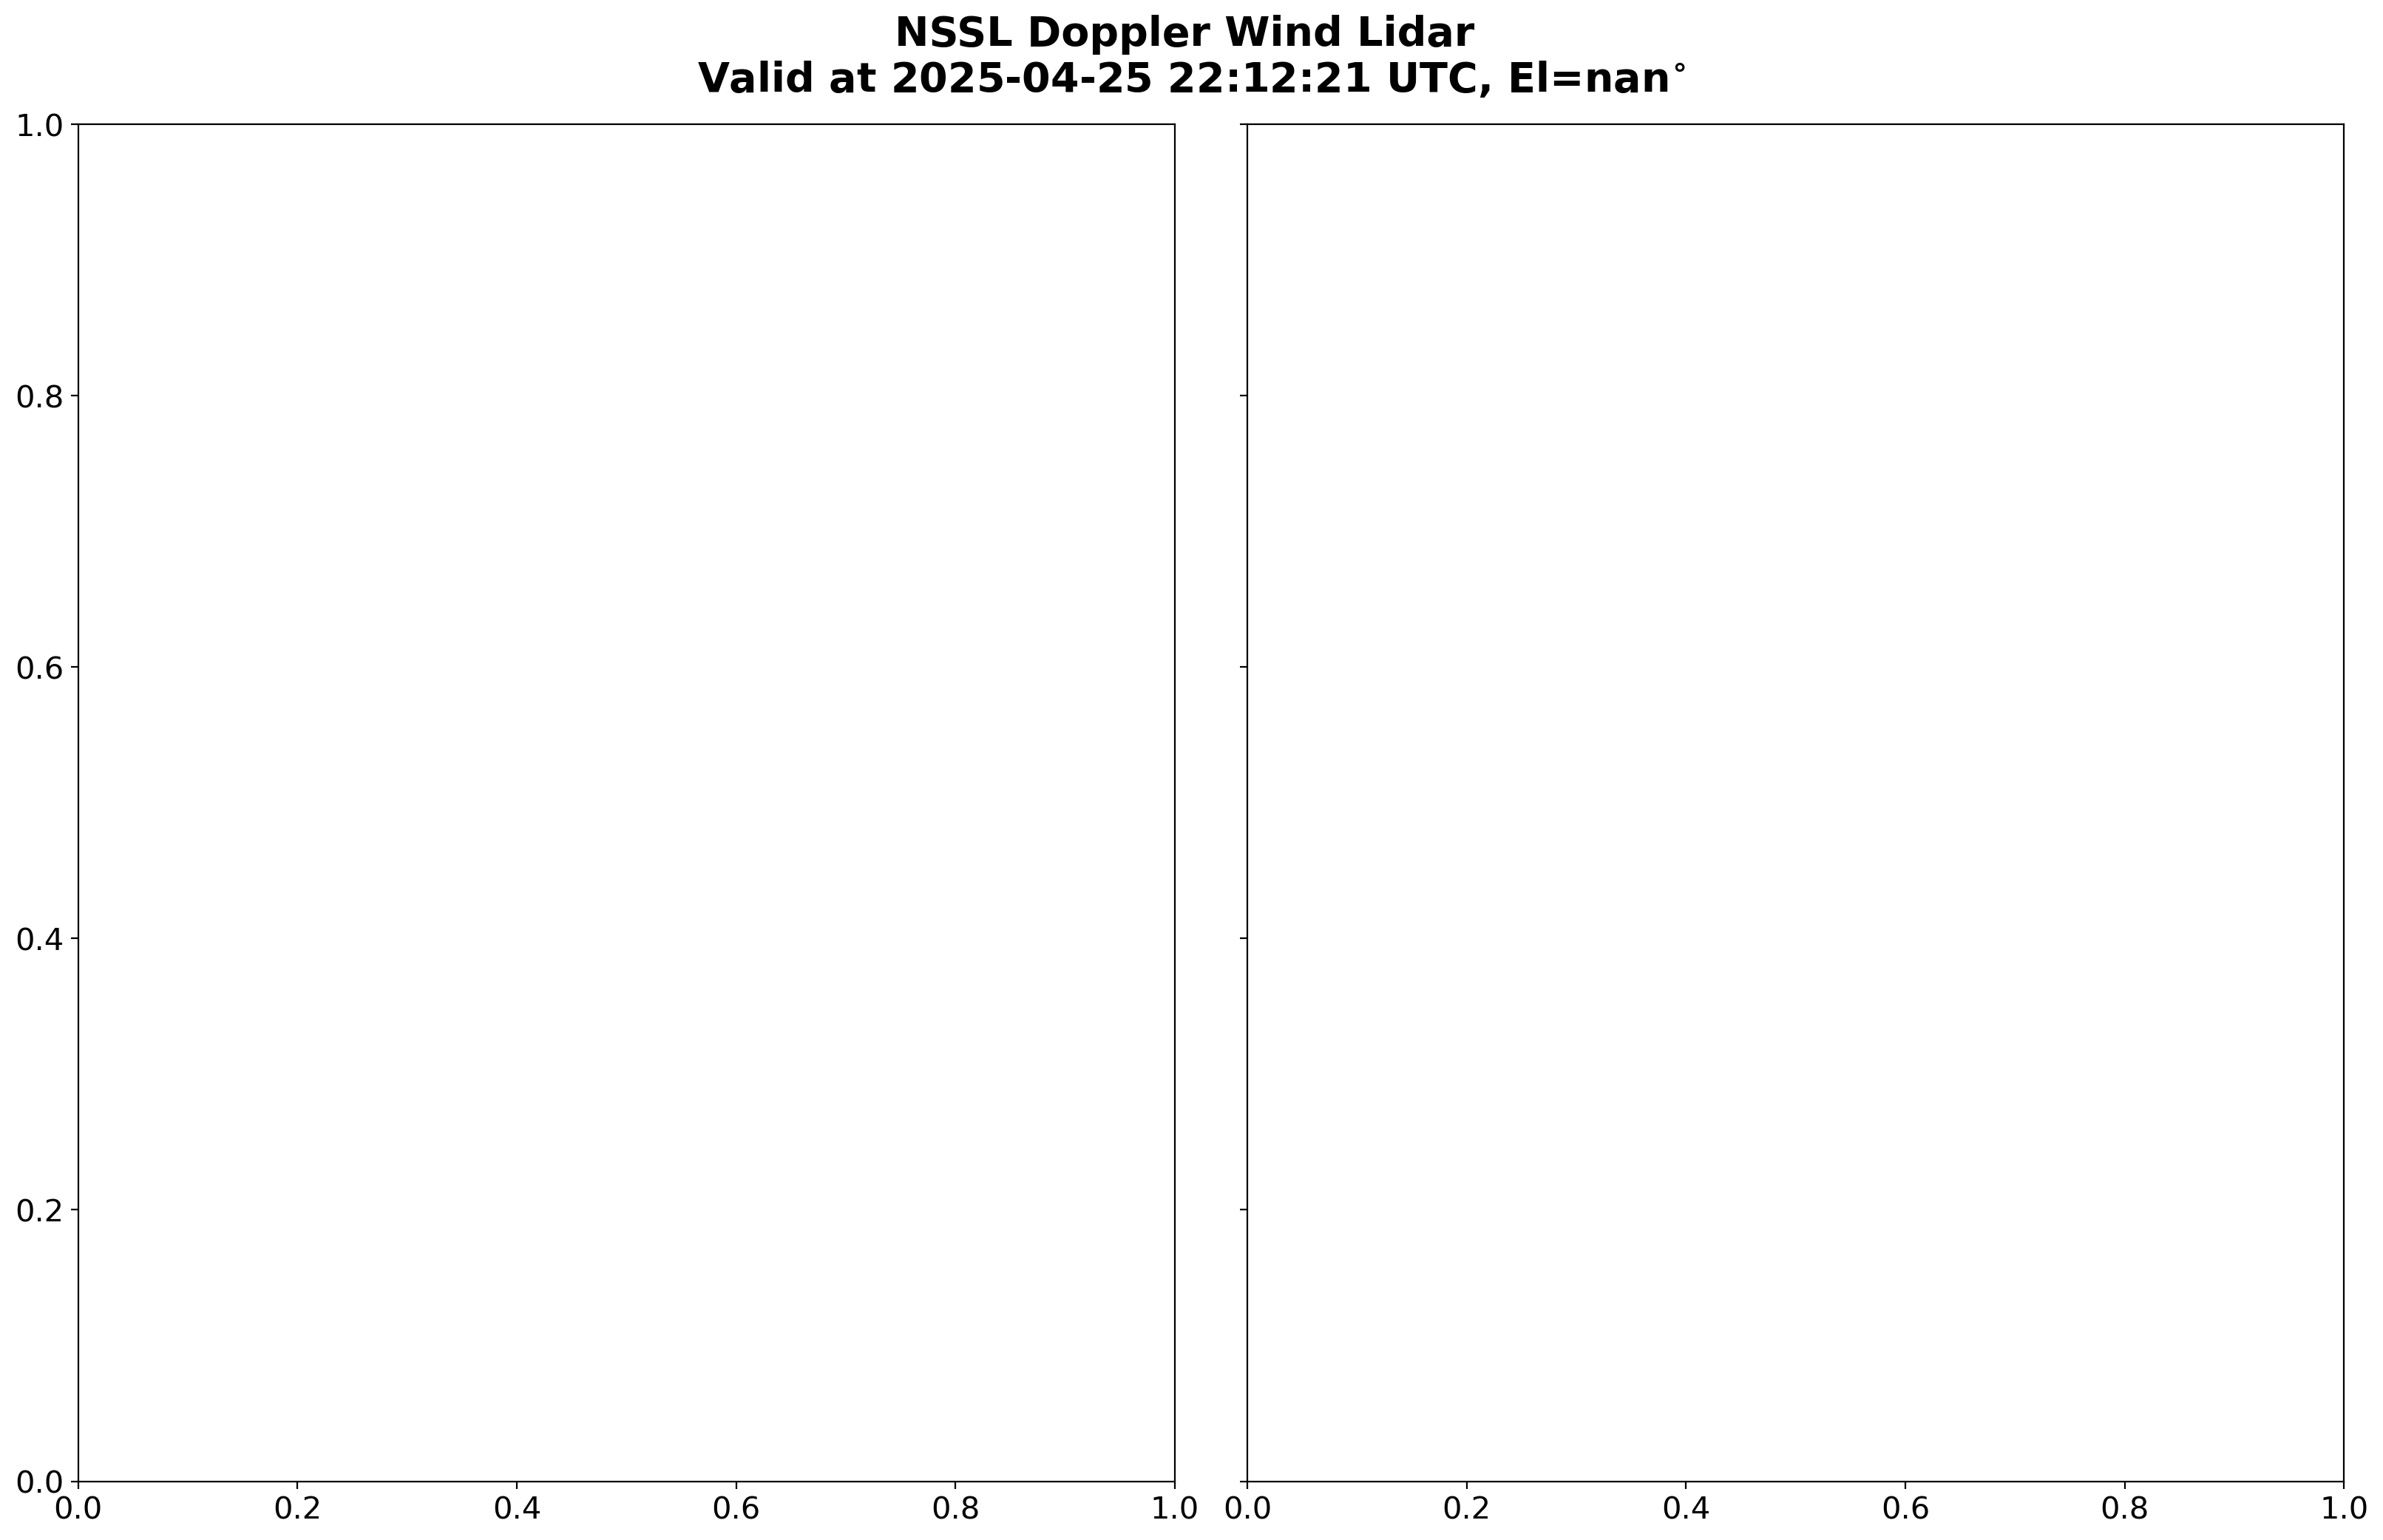

In [17]:
# def get_scan_vars(scan_number, unique_snum, el, az, hour, vr, time):
#     usidx = unique_snum[scan_number]

#     sidx = np.where(usidx == snum)
#     scan_el = el[sidx]
#     scan_az = az[sidx]
#     scan_hr = hour[sidx]
#     scan_vr = vr[sidx[0],:]
#     scan_time = time[sidx]
#     sort_index = np.argsort(scan_hr)
#     scan_el = scan_el[sort_index]
#     scan_az = scan_az[sort_index]
#     scan_hr = scan_hr[sort_index]
#     scan_vr = scan_vr[sort_index,:]
#     scan_time = scan_time[sort_index]

#     x, y = dis_angle_to_2Dxy(r,north0_to_arctheta(scan_az))
#     x, y = x.T, y.T

#     return scan_el, scan_az, scan_hr, scan_vr, scan_time, x, y

foo = np.where(r > 8)[0]
vr[:,foo] = np.nan

unique_snum = np.unique(snum)

d01 = ccrs.LambertConformal(central_longitude=-99.562789, central_latitude=34.584454,standard_parallels=(30,60))

lidar_position = True
for i in unique_snum:
    foo = np.where(i == snum)
    
    scan_el = el[foo]
    scan_az = az[foo]
    scan_hr = hour[foo]
    scan_vr = vr[foo[0],:]
    scan_snr = snr[foo[0],:]
    scan_time = time[foo]
    sort_index = np.argsort(scan_hr)
    
    scan_el = scan_el[sort_index]
    scan_az = scan_az[sort_index]
    scan_hr = scan_hr[sort_index]
    scan_vr = scan_vr[sort_index,:]
    scan_snr = scan_snr[sort_index,:]
    scan_time = scan_time[sort_index]
    
    az_1 = []
    el_1 = []
    hr_1 = []
    vr_1 = []
    snr_1 = []
    scan_time1 = []
    az_2 = []
    el_2 = []
    hr_2 = []
    vr_2 = []
    snr_2 = []
    scan_time2 = []
    
    sign = 0
    switch = False
    for j in range(1,len(scan_az)):
        direction = np.sign(scan_az[j]-scan_az[j-1])
        if j == 1:
            sign = np.copy(direction)
            az_1.append(scan_az[j-1])
            el_1.append(scan_el[j-1])
            hr_1.append(scan_hr[j-1])
            vr_1.append(scan_vr[j-1,:])
            snr_1.append(scan_snr[j-1,:])
            scan_time1.append(scan_time[j-1])
        
        else:
            if (sign == direction) and not switch:
                az_1.append(scan_az[j-1])
                el_1.append(scan_el[j-1])
                hr_1.append(scan_hr[j-1])
                vr_1.append(scan_vr[j-1,:])
                snr_1.append(scan_snr[j-1,:])
                scan_time1.append(scan_time[j-1])
            elif (sign == direction) and switch:
                az_2.append(scan_az[j-1])
                el_2.append(scan_el[j-1])
                hr_2.append(scan_hr[j-1])
                vr_2.append(scan_vr[j-1,:])
                snr_2.append(scan_snr[j-1,:])
                scan_time2.append(scan_time[j-1])
            else:
                if not switch:
                    switch = True
                    if abs(direction) > 0.1:
                        sign = np.copy(direction)
                    else:
                        sign = sign*-1
                    az_1.append(scan_az[j-1])
                    el_1.append(scan_el[j-1])
                    hr_1.append(scan_hr[j-1])
                    vr_1.append(scan_vr[j-1,:])
                    snr_1.append(scan_snr[j-1,:])
                    scan_time1.append(scan_time[j-1])
                else:
                    if scan_az[j]-scan_az[j-1] == 0:
                        continue
                    else:
                        # The direction should never switch twice
                        break
    
    az_1 = np.array(az_1)
    el_1 = np.array(el_1)
    hr_1 = np.array(hr_1)
    vr_1 = np.array(vr_1)
    snr_1 = np.array(snr_1)
    scan_time1 = np.array(scan_time1)
    az_2 = np.array(az_2)
    el_2 = np.array(el_2)
    hr_2 = np.array(hr_2)
    vr_2 = np.array(vr_2)
    snr_2 = np.array(snr_2)
    scan_time2 = np.array(scan_time2)

    for j in range(2):
        
        if j == 0:
            if len(az_1) == 0:
                continue
            
            foo = np.where((scan_time1[0] <= mtime) & (scan_time1[-1] >= mtime))
            scan1_heading = m_heading[foo]
            scan1_cheading = np.nanmean(c_heading[foo])
            scan_lat = np.nanmean(lat[foo])
            scan_lon = np.nanmean(lon[foo])
            
            
            az_1 = (az_1 + scan1_cheading ) % 360
            
            if lidar_position:
                lidar_x0, lidar_y0 = d01.transform_point(scan_lon,scan_lat,src_crs=ccrs.Geodetic())
                lidar_position = False
            
            lidar_x, lidar_y = d01.transform_point(scan_lon,scan_lat,src_crs=ccrs.Geodetic())
            
            x = r[None,:]*np.sin(np.radians(az_1[:,None]))*np.cos(np.radians(np.nanmean(el_1)))*1000# + lidar_x
            y = r[None,:]*np.cos(np.radians(az_1[:,None]))*np.cos(np.radians(np.nanmean(el_1)))*1000# + lidar_y
            
            vort = ((vr_1[2:,:]-vr_1[:-2,:])/((np.deg2rad(az_1[2:])-np.deg2rad(az_1[:-2]))[:,None]))/(r[None,:]*1000)

    # mask out low snr
    # snr_mask = snr_1 > -25
    # vr_1_masked = np.where(snr_mask, vr_1, np.nan)
    # vort_masked = np.where(snr_mask[1:-1], vort, np.nan)
        
    # make figure
    fig, axs = plt.subplots(figsize=(16,10.3),
                            ncols=2,
                            sharey=True,
                            constrained_layout=True,
                            dpi=200)
    # time
    hr = np.nanmean(hr_1)
    if np.isnan(hr):
        continue
    mi = (hr - int(hr)) * 60
    se = (mi - int(mi)) * 60
    hr, mi, se = int(hr), int(mi), int(se)
    tdt = datetime(2025, 4, 25, hr, mi, se)
    tstr = datetime.strftime(tdt, "%Y%m%d_%H%M%S")
    # elevation
    elplt = np.nanmean(el_2)
    # fig title
    fig.suptitle(f"NSSL Doppler Wind Lidar \nValid at {tdt} UTC, El={elplt:.2f}$\\bf{{^{{\\circ}}}}$", 
                 fontsize=20, fontweight='bold')
    
    # radial velocity
    ax = axs[0]
    pcm = ax.pcolormesh(x/1e3, y/1e3, vr_1,
                        cmap='pyart_Carbone42',
                        vmin=-38, vmax=38)
    ax.set_title("Radial Velocity")
    cbar = plt.colorbar(pcm, ax=ax, 
                        orientation="horizontal", 
                        label="$V_r$ [m s$^{-1}$]",
                        pad=0.03)
    ax.set_ylabel("Meridional Distance [km]")
    # zeta
    ax = axs[1]
    pcm = ax.pcolormesh(x[1:-1,:]/1e3, y[1:-1,:]/1e3, vort,
                        cmap='RdBu_r',
                        vmin=-0.05, vmax=0.05)
    ax.set_title("Inferred Vertical Vorticity")
    cbar = plt.colorbar(pcm, ax=ax, 
                        orientation="horizontal", 
                        label="$\\zeta$ [s$^{-1}$]",
                        pad=0.03)
    
    for ax in axs:
        ax.set_aspect('equal')
        ax.grid(alpha=0.5)
        ax.set_xlabel("Zonal Distance [km]")
        ax.set_xlim(-9,0)
        ax.set_ylim(-2,7)

    dout = f"{dfig}{tstr}_vr_zeta.png"
    plt.savefig(dout)
    plt.close()
    print(f"Saved to: {dout}\n")